In [ ]:
import os

for f in os.listdir('/content'):
    print(f)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import zipfile

with zipfile.ZipFile('/MRI.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/brain_tumor_dataset')

print("Done!")

Done!


In [ ]:
import os

print("Training folders:")
for folder in os.listdir('/content/brain_tumor_dataset/Training'):
    print(" ", folder)

print("\nTesting folders:")
for folder in os.listdir('/content/brain_tumor_dataset/Testing'):
    print(" ", folder)

Training folders:
  pituitary
  notumor
  meningioma
  glioma

Testing folders:
  pituitary
  notumor
  meningioma
  glioma


In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

train_dir = '/content/brain_tumor_dataset/Training'
test_dir  = '/content/brain_tumor_dataset/Testing'

Using device: cuda


In [ ]:
import torchvision.transforms as transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms ready!")

Transforms ready!


In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dataset = ImageFolder(root=train_dir, transform=train_transforms)
test_dataset  = ImageFolder(root=test_dir,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Training images:  {len(train_dataset)}")
print(f"Testing images:   {len(test_dataset)}")
print(f"Classes:          {train_dataset.classes}")

Training images:  5600
Testing images:   1600
Classes:          ['glioma', 'meningioma', 'notumor', 'pituitary']


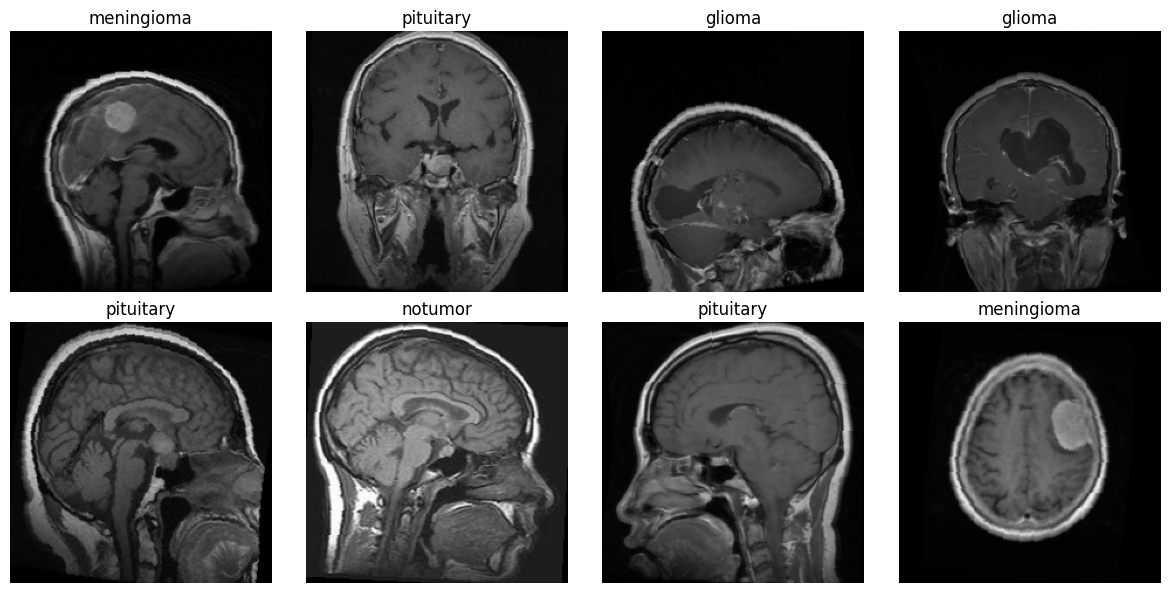

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    img = images[i].numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = std * img + mean
    img  = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(train_dataset.classes[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 4)

model = model.to(device)

print(model.fc)
print("Model ready!")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 71.8MB/s]


Linear(in_features=2048, out_features=4, bias=True)
Model ready!


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Loss function and optimizer ready!")

Loss function and optimizer ready!


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {train_loss:.4f} — Accuracy: {train_acc:.2f}%")

print("Training done!")

Epoch 1/10 — Loss: 0.6333 — Accuracy: 76.46%
Epoch 2/10 — Loss: 0.4494 — Accuracy: 83.45%
Epoch 3/10 — Loss: 0.4031 — Accuracy: 85.41%
Epoch 4/10 — Loss: 0.3569 — Accuracy: 87.04%
Epoch 5/10 — Loss: 0.3630 — Accuracy: 86.80%
Epoch 6/10 — Loss: 0.3498 — Accuracy: 87.02%
Epoch 7/10 — Loss: 0.3302 — Accuracy: 87.62%
Epoch 8/10 — Loss: 0.3193 — Accuracy: 88.16%
Epoch 9/10 — Loss: 0.3211 — Accuracy: 87.80%
Epoch 10/10 — Loss: 0.3197 — Accuracy: 87.91%
Training done!


In [ ]:
model.eval()
correct = 0
total   = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs   = model(images)
        _, predicted = torch.max(outputs, 1)
        total    += labels.size(0)
        correct  += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 85.19%


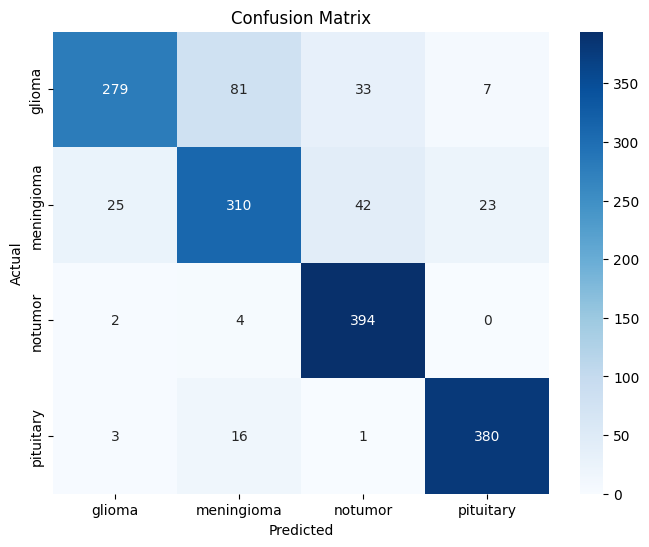

              precision    recall  f1-score   support

      glioma       0.90      0.70      0.79       400
  meningioma       0.75      0.78      0.76       400
     notumor       0.84      0.98      0.91       400
   pituitary       0.93      0.95      0.94       400

    accuracy                           0.85      1600
   macro avg       0.86      0.85      0.85      1600
weighted avg       0.86      0.85      0.85      1600



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.00001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    train_acc  = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{5} — Loss: {train_loss:.4f} — Accuracy: {train_acc:.2f}%")

print("Fine tuning done!")

Epoch 1/5 — Loss: 0.2111 — Accuracy: 92.20%
Epoch 2/5 — Loss: 0.1214 — Accuracy: 95.64%
Epoch 3/5 — Loss: 0.0810 — Accuracy: 97.18%
Epoch 4/5 — Loss: 0.0561 — Accuracy: 97.89%
Epoch 5/5 — Loss: 0.0358 — Accuracy: 98.84%
Fine tuning done!


Test Accuracy: 94.19%


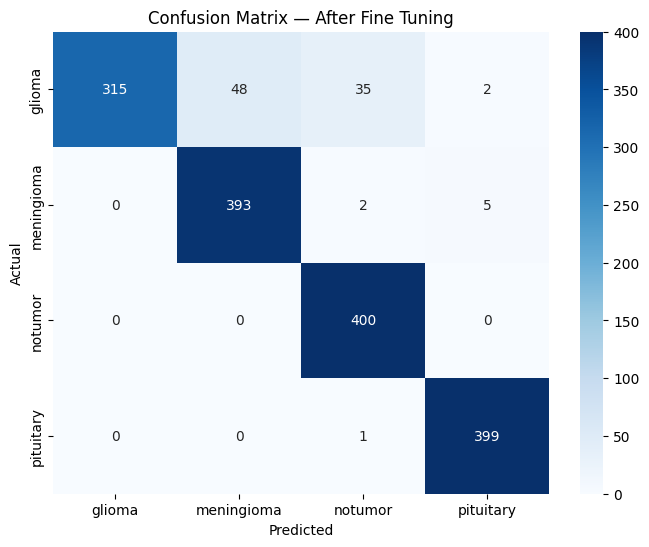

              precision    recall  f1-score   support

      glioma       1.00      0.79      0.88       400
  meningioma       0.89      0.98      0.93       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



In [ ]:
model.eval()
correct = 0
total   = 0

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total    += labels.size(0)
        correct  += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — After Fine Tuning')
plt.show()

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

In [ ]:
torch.save(model.state_dict(), '/content/brain_tumor_resnet50.pth')
print("Model saved!")

Model saved!


In [ ]:
from google.colab import files
files.download('/content/brain_tumor_resnet50.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def show_gradcam(model, dataset, img_index):
    gradcam = GradCAM(model, model.layer4[-1])

    img_tensor, true_label = dataset[img_index]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    cam, predicted_idx = gradcam.generate(input_tensor)

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_tensor.numpy().transpose(1, 2, 0)
    img  = std * img + mean
    img  = np.clip(img, 0, 1)

    cam_resized = cv2.resize(cam, (224, 224))

    heatmap = plt.cm.jet(cam_resized)[:, :, :3]

    overlay = 0.5 * img + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(img)
    axes[0].set_title(f'Original\nActual: {dataset.classes[true_label]}')
    axes[0].axis('off')

    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay\nPredicted: {dataset.classes[predicted_idx]}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


--- GLIOMA ---


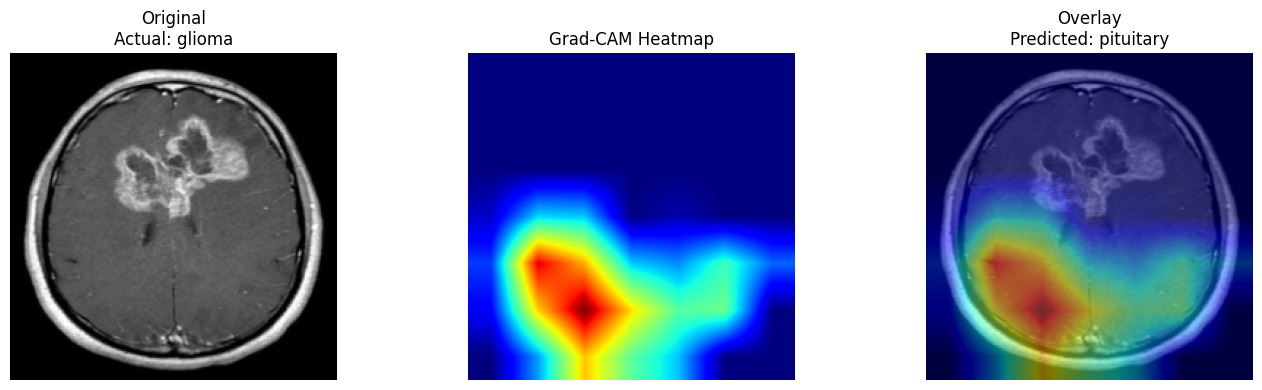


--- MENINGIOMA ---


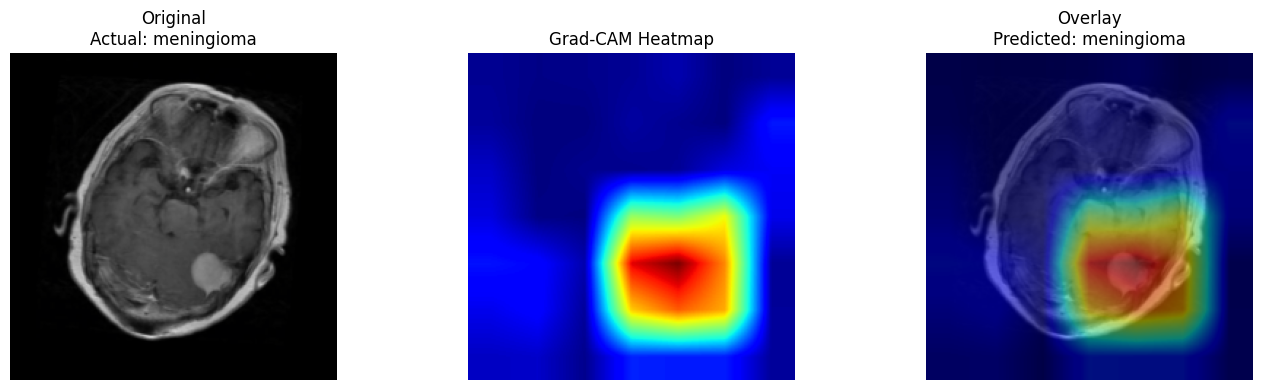


--- NOTUMOR ---


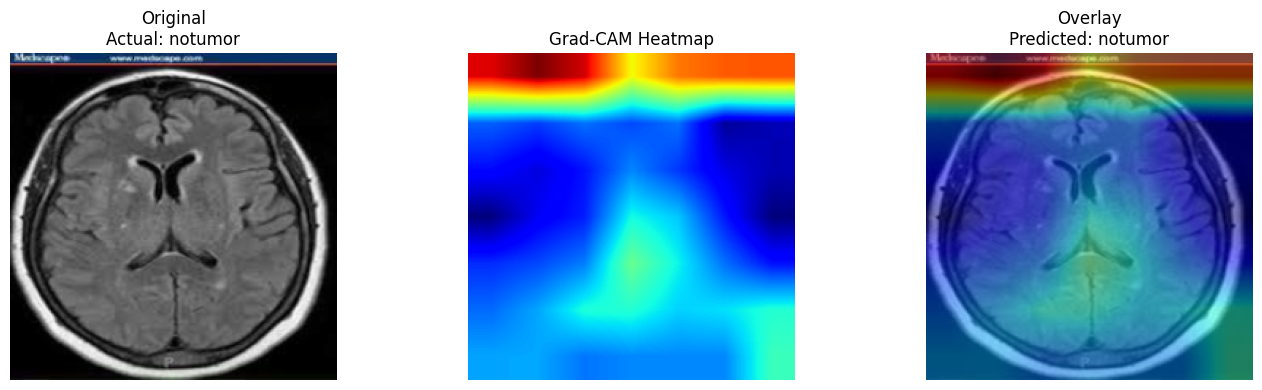


--- PITUITARY ---


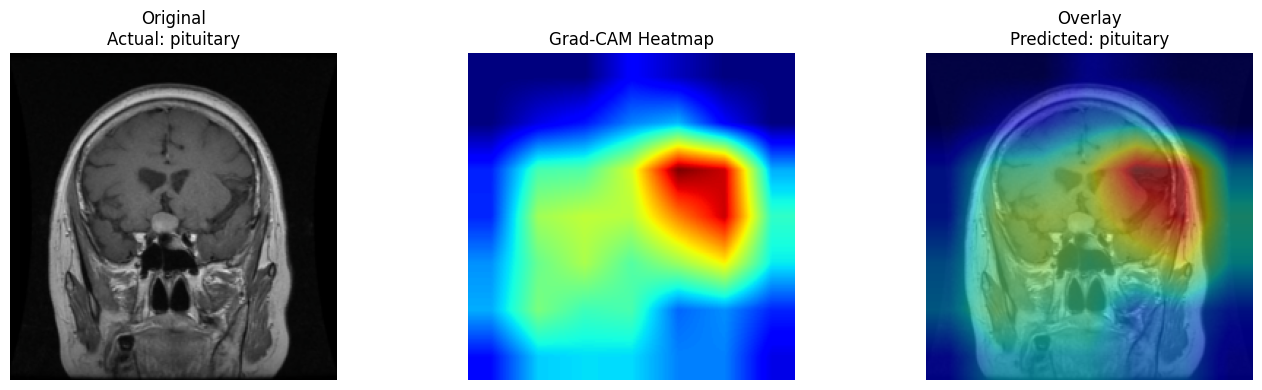

In [ ]:
class_indices = {
    'glioma':      0,
    'meningioma':  400,
    'notumor':     800,
    'pituitary':   1200
}

for class_name, idx in class_indices.items():
    print(f"\n--- {class_name.upper()} ---")
    show_gradcam(model, test_dataset, idx)

In [ ]:
from google.colab import files
files.download('/content/brain_tumor_resnet50.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>